# Hyperparameter search and confirmation

Results are in `tuning/results/search_results.csv`. Total came out to 24 studies: 4 architectures x 3 frame rates x 2 window lengths.
For each study there were 20 TPE trial runs, and the search score was just the mean across 3 seeds. 

Then the top two were taken, reran them on 5 fresh seeds (confirm), and went with whichever had the higher confirmed mean (selected).

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from dataclasses import asdict

from attention_lapse_detection.training.selection import CELL, select
from attention_lapse_detection.utils.hyperparameters import load_hyperparameters
from attention_lapse_detection.utils.paths import PATHS

In [20]:
search_results = pd.read_csv(PATHS.root / "tuning/results/search_results.csv")
HYPERPARAMETERS = [
    "hidden_size",
    "num_layers",
    "dropout",
    "learning_rate",
    "batch_size",
]

search = search_results[search_results.stage == "search"]
confirm_rows = search_results[search_results.stage == "confirm"]

search_section = search[CELL + HYPERPARAMETERS + ["ap", "sem"]]

confirmed = confirm_rows.merge(
    search_section, on=CELL + HYPERPARAMETERS, suffixes=("_confirm", "_search")
)


count_study = search.groupby(CELL).ngroups
count_selected = confirmed.selected.sum()

print(
    f"{count_study} studies, {len(search)} search rows, "
    f"{len(confirmed)} confirmed candidates, {count_selected} selected"
)

24 studies, 480 search rows, 48 confirmed candidates, 24 selected


## Table 6.1 Search and confirmation 

In [21]:
MODEL, FPS, WINDOW = select(
    pd.read_csv(PATHS.root / "experiments/results/thesis_runs.csv")
)

winner_candidates = (
    (confirmed.model == MODEL)
    & (confirmed.fps == FPS)
    & (confirmed.window_seconds == WINDOW)
)

candidates = confirmed[winner_candidates].sort_values("ap_search", ascending=False)

table_rows = []
rank = 1

for _, row in candidates.iterrows():
    search_sd = row.sem_search * 3 / np.sqrt(3 - 1)
    confirm_sd = row.sem_confirm * 5 / np.sqrt(5 - 1)

    if row.selected:
        selected_text = "yes"
    else:
        selected_text = "no"

    table_rows.append(
        {
            "Candidate": f"Search rank {rank}",
            "Units / layers": f"{row.hidden_size} / {row.num_layers}",
            "Dropout": f"{row.dropout:.2f}",
            "Learning rate": f"{row.learning_rate:.2e}",
            "Batch": row.batch_size,
            "Search AP (plus-minus) SD (3 seeds)": f"{row.ap_search:.4f} (plus-minus) {search_sd:.4f}",
            "Confirmation AP (plus-minus) SD (5 seeds)": f"{row.ap_confirm:.4f} (plus-minus) {confirm_sd:.4f}",
            "Selected": selected_text,
        }
    )

    rank += 1

pd.DataFrame(table_rows).set_index("Candidate")

,Units / layers,Dropout,Learning rate,Batch,Search AP (plus-minus) SD (3 seeds),Confirmation AP (plus-minus) SD (5 seeds),Selected
Candidate,,,,,,,
Search rank 1,133 / 3,0.05,4.65e-04,16,0.2916 (plus-minus) 0.0038,0.2526 (plus-minus) 0.0351,no
Search rank 2,105 / 2,0.05,5.34e-04,64,0.2836 (plus-minus) 0.0055,0.2716 (plus-minus) 0.0186,yes


## Adopted settings, all 24 studies (appendix)
For the five-seed confirmation runs, the means were cross checked against `hyperparameters/values.json`. The stored SEM is the standard deviation divided by `sqrt(n)`. Here it is converted to the conventional sample SEM by x sqrt(5/4).


In [37]:
selected = confirmed.loc[confirmed.selected].set_index(CELL).sort_index()

searched = pd.DataFrame.from_dict(
    {key: asdict(h) for key, h in load_hyperparameters().items()}, orient="index"
)

print(
    "Selected settings match JSON:",
    np.allclose(
        selected.loc[:, HYPERPARAMETERS].to_numpy(float),
        searched.loc[selected.index, HYPERPARAMETERS].to_numpy(float),
    ),
)

selected_settings = selected.loc[:, HYPERPARAMETERS + ["params", "ap_confirm"]].copy()

selected_settings["sample_sem_confirm"] = selected.sem_confirm * (5 / 4) ** 0.5
selected_settings["learning_rate"] = [f"{x:.2e}" for x in selected_settings.learning_rate]
selected_settings["ap_confirm"] = [f"{x:.4f}" for x in selected_settings.ap_confirm]

selected_settings["sample_sem_confirm"] = [
    f"{x:.4f}" for x in selected_settings.sample_sem_confirm
]

selected_settings

Selected settings match JSON: True


hidden_size  ...  sample_sem_confirm
model              fps window_seconds               ...                    
gru                10  5                        95  ...              0.0094
                       10                       48  ...              0.0087
                   15  5                        47  ...              0.0043
                       10                       31  ...              0.0118
                   30  5                       136  ...              0.0041
                       10                       40  ...              0.0071
gru_uni_attention  10  5                       107  ...              0.0072
                       10                      105  ...              0.0083
                   15  5                       108  ...              0.0100
                       10                      200  ...              0.0183
                   30  5                       108  ...              0.0095
                       10                      200  ...              0.0041
lstm               10  5                       179  ...              0.0036
                       10                      120  ...              0.0032
                   15  5                       193  ...              0.0109
                       10                       70  ...              0.0036
                   30  5                       179  ...              0.0066
                       10                       70  ...              0.0072
lstm_uni_attention 10  5                        70  ...              0.0055
                       10                      126  ...              0.0049
                   15  5                        70  ...              0.0053
                       10                      136  ...              0.0059
                   30  5                       162  ...              0.0099
                       10                       94  ...              0.0020

[24 rows x 8 columns]

## Did confirmation change the preferred candidate?

For each study the best search candidate (3 seeds) is compared with the configuration selected after confirmation (5 seeds).

In [38]:
phases = selected.loc[:, ["ap_search", "ap_confirm"]].copy()

phases["search_max"] = search.groupby(CELL).ap.max()
phases["selected_is_search_leader"] = phases.ap_search == phases.search_max

n = len(phases)

print(f"Total studies: {n}")
print(f"Confirmation changed the winner in {(~phases.selected_is_search_leader).sum()}")
print(
    f"Confirmation mean below the search maximum in {(phases.ap_confirm < phases.search_max).sum()}"
)
print(
    f"Confirmation mean below the same candidate's search mean in {(phases.ap_confirm < phases.ap_search).sum()}"
    f"(mean change {(phases.ap_confirm - phases.ap_search).mean():.4f})"
)
phases

Total studies: 24
Confirmation changed the winner in 13
Confirmation mean below the search maximum in 23
Confirmation mean below the same candidate's search mean in 22(mean change -0.0108)


ap_search  ...  selected_is_search_leader
model              fps window_seconds             ...                           
gru                10  5                0.245199  ...                      False
                       10               0.233369  ...                       True
                   15  5                0.234583  ...                       True
                       10               0.228224  ...                       True
                   30  5                0.233286  ...                       True
                       10               0.222877  ...                      False
gru_uni_attention  10  5                0.287611  ...                      False
                       10               0.283610  ...                      False
                   15  5                0.286808  ...                       True
                       10               0.280118  ...                      False
                   30  5                0.277892  ...                       True
                       10               0.281958  ...                      False
lstm               10  5                0.230495  ...                      False
                       10               0.223984  ...                      False
                   15  5                0.233765  ...                       True
                       10               0.221329  ...                      False
                   30  5                0.220396  ...                       True
                       10               0.217118  ...                      False
lstm_uni_attention 10  5                0.261641  ...                      False
                       10               0.283047  ...                      False
                   15  5                0.265223  ...                      False
                       10               0.286337  ...                       True
                   30  5                0.264615  ...                       True
                       10               0.281322  ...                       True

[24 rows x 4 columns]

## Supporting: the same candidate across phases (appendix)

All 48 confirmed candidates, each plotted at its search mean against its confirmation mean. The metric is validation AP for the disengaged

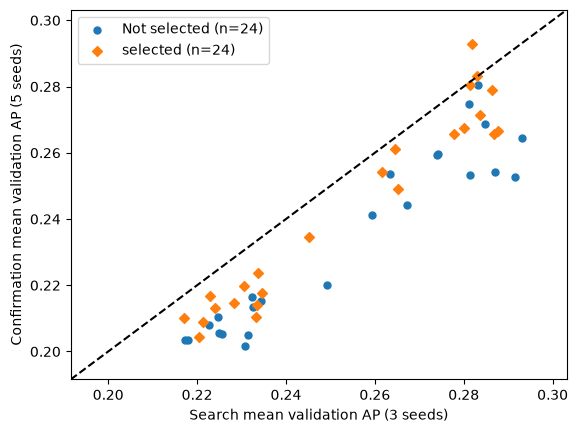

In [35]:
fig, ax = plt.subplots()
for is_selected, group in confirmed.groupby("selected"):
    ax.scatter(
        group.ap_search,
        group.ap_confirm,
        s=25,
        marker="D" if is_selected else "o",
        label=f"{'selected' if is_selected else 'Not selected'} (n={len(group)})",
    )

limits = (
    confirmed[["ap_search", "ap_confirm"]].min().min() - 0.01,
    confirmed[["ap_search", "ap_confirm"]].max().max() + 0.01,
)

ax.plot(limits, limits, "k--")

ax.set(
    xlim=limits,
    ylim=limits,
    xlabel="Search mean validation AP (3 seeds)",
    ylabel="Confirmation mean validation AP (5 seeds)",
)
ax.legend(loc="upper left")
plt.show()